<a href="https://colab.research.google.com/github/WVF-1/Audience-Analytics/blob/main/NB9_Extended_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Audience Ratings Behaviour — Extended Insights
## Six Data-Driven Findings for the Newsletter

**Series:** May Newsletter — Movie Intelligence (Part 3 of 3)  
**Prerequisite:** `audience_clean.parquet` from Notebook 7

This notebook builds six figures around specific, quantifiable findings in the data rather than
summary rankings. Each figure is designed to *reveal a mechanism*, not just describe the dataset.

| Figure | Finding | Key stat |
|--------|---------|----------|
| A | Revenue tells us nothing — but ROI does | r(revenue, rating) = −0.02 vs ROI trend |
| B | Survivor bias: older films rate higher | 1960s avg 3.85 vs 1990s avg 3.33 |
| C | Crowd wisdom: more ratings → higher scores | r(log count, rating) = 0.34 |
| D | Genre quality vs polarisation matrix | Drama: loved & calm. Horror: mixed & loud |
| E | Where the two rating systems disagree | TMDB vs MovieLens divergence map |
| F | The full picture: financial efficiency predicts quality | ROI bucket → audience score staircase |


## 0 · Setup & Data Reconstruction

In [16]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

import pandas as pd
import numpy as np
import ast
from scipy.stats import pearsonr, spearmanr, sem
import warnings
warnings.filterwarnings("ignore")

# ── Reconstruct pipeline (mirrors NB7) ───────────────────────────────
# If audience_clean.parquet already exists, load it directly instead.
import os
if os.path.exists("audience_clean.parquet"):
    df = pd.read_parquet("audience_clean.parquet")
    print(f"Loaded audience_clean.parquet — {len(df):,} films")
else:
    print("Rebuilding from raw files…")
    df_raw = pd.read_csv("movies_metadata.csv", low_memory=False)
    df_raw["budget"]       = pd.to_numeric(df_raw["budget"],       errors="coerce").replace(0, np.nan)
    df_raw["revenue"]      = pd.to_numeric(df_raw["revenue"],      errors="coerce").replace(0, np.nan)
    df_raw["vote_average"] = pd.to_numeric(df_raw["vote_average"], errors="coerce")
    df_raw["vote_count"]   = pd.to_numeric(df_raw["vote_count"],   errors="coerce")
    df_raw["popularity"]   = pd.to_numeric(df_raw["popularity"],   errors="coerce")

    def parse_genre_list(raw):
        try: return [g["name"] for g in ast.literal_eval(str(raw)) if isinstance(g, dict)]
        except: return []

    df_raw["primary_genre"] = df_raw["genres"].apply(lambda x: (parse_genre_list(x) or ["Unknown"])[0])
    df_raw["release_date"]  = pd.to_datetime(df_raw["release_date"], errors="coerce")
    df_raw["release_year"]  = df_raw["release_date"].dt.year
    df_raw["decade"]        = (df_raw["release_year"] // 10 * 10)
    df_raw["profit"]        = df_raw["revenue"] - df_raw["budget"]
    df_raw["ROI"]           = (df_raw["revenue"] - df_raw["budget"]) / df_raw["budget"]
    df_raw["id"]            = df_raw["id"].astype(str).str.strip()

    mask = (df_raw["budget"].notna() & df_raw["revenue"].notna() &
            (df_raw["vote_count"] >= 10) & (df_raw["status"] == "Released") &
            (df_raw["adult"] == "False"))
    movies = df_raw[mask].copy()

    ratings = pd.read_csv("ratings_small.csv")
    links   = pd.read_csv("links.csv")
    links["tmdbId"]    = pd.to_numeric(links["tmdbId"], errors="coerce")
    links              = links.dropna(subset=["tmdbId"])
    links["tmdbId"]    = links["tmdbId"].astype(int).astype(str)
    links["movieId"]   = links["movieId"].astype(str)
    ratings["movieId"] = ratings["movieId"].astype(str)

    film_ratings = ratings.groupby("movieId").agg(
        avg_user_rating = ("rating", "mean"),
        rating_std      = ("rating", "std"),
        rating_count    = ("rating", "count"),
        pct_5star       = ("rating", lambda x: (x == 5.0).mean() * 100),
        pct_low         = ("rating", lambda x: (x <= 2.0).mean() * 100),
    ).reset_index()
    film_ratings["rating_std"] = film_ratings["rating_std"].fillna(0)

    linked = film_ratings.merge(
        links[["movieId","tmdbId"]].rename(columns={"tmdbId":"id"}),
        on="movieId", how="inner")

    df = movies.merge(linked, on="id", how="inner")
    df = df[df["rating_count"] >= 10].copy()
    print(f"Built from raw files — {len(df):,} films")

# Shared derived columns
df["log_count"]   = np.log10(df["rating_count"])
df["ROI_capped"]  = df["ROI"].clip(-1, 20)
df["roi_bucket"]  = pd.cut(df["ROI_capped"],
                            bins=[-1, 0, 1, 3, 10, 20],
                            labels=["Flop\n(<0×)", "Marginal\n(0–1×)",
                                    "Solid\n(1–3×)", "Hit\n(3–10×)", "Smash\n(>10×)"])
df["vote_norm"]   = (df["vote_average"] - df["vote_average"].min()) /                     (df["vote_average"].max()  - df["vote_average"].min())
df["rating_norm"] = (df["avg_user_rating"] - 0.5) / 4.5
df["score_gap"]   = df["rating_norm"] - df["vote_norm"]   # positive = users > TMDB

print(f"\nKey correlations:")
r_rev,  _ = pearsonr(df["avg_user_rating"], df["revenue"])
r_roi,  _ = pearsonr(df["avg_user_rating"], df["ROI_capped"])
r_cnt,  _ = pearsonr(df["avg_user_rating"], df["log_count"])
r_yr,   _ = pearsonr(df["avg_user_rating"], df["release_year"].dropna())
r_sys,  _ = pearsonr(df["vote_norm"],        df["rating_norm"])
print(f"  Rating vs Revenue      r = {r_rev:.3f}  ← near zero")
print(f"  Rating vs ROI          r = {r_roi:.3f}")
print(f"  Rating vs log(count)   r = {r_cnt:.3f}")
print(f"  Rating vs release year r = {r_yr:.3f}  ← older = higher")
print(f"  TMDB vs MovieLens      r = {r_sys:.3f}  ← strong but not perfect")


Loaded audience_clean.parquet — 1,657 films

Key correlations:
  Rating vs Revenue      r = -0.015  ← near zero
  Rating vs ROI          r = 0.235
  Rating vs log(count)   r = 0.342
  Rating vs release year r = -0.254  ← older = higher
  TMDB vs MovieLens      r = 0.842  ← strong but not perfect


## Figure A · Revenue Tells Us Nothing — But ROI Does

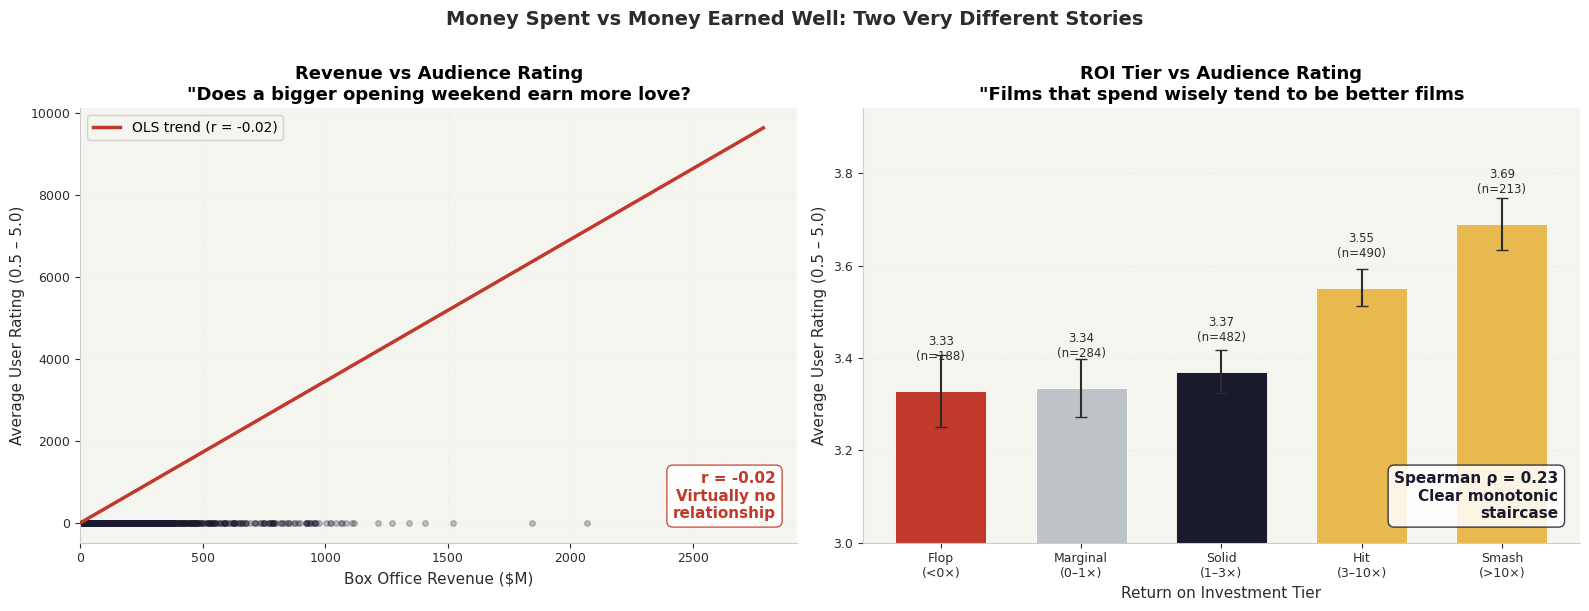

Saved: fig_A_revenue_vs_roi.png
  Revenue–rating r = -0.015
  ROI–rating ρ    = 0.235


In [17]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Money Spent vs Money Earned Well: Two Very Different Stories",
             fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.01)

r_rev, _ = pearsonr(df["avg_user_rating"], df["revenue"])

# ── Left: Revenue vs rating — the non-relationship ─────────────────
ax = axes[0]
ax.scatter(df["revenue"]/1e6, df["avg_user_rating"],
           color=MIDNIGHT, alpha=0.25, s=16, zorder=2)

# Flat OLS line to make the point visually
from numpy.polynomial.polynomial import polyfit as npfit
b, m = npfit(df["revenue"]/1e6, df["avg_user_rating"], deg=1)
xs = np.linspace(0, df["revenue"].max()/1e6, 200)
ax.plot(xs, m + b*xs, color=CRIMSON, linewidth=2.5,
        label=f"OLS trend (r = {r_rev:.2f})", zorder=4)

ax.set_xlabel("Box Office Revenue ($M)", fontsize=11)
ax.set_ylabel("Average User Rating (0.5 – 5.0)", fontsize=11)
ax.set_title("""Revenue vs Audience Rating
"Does a bigger opening weekend earn more love?""")
ax.legend(fontsize=10, framealpha=0.85)
ax.text(0.97, 0.05,
        f"r = {r_rev:.2f}\nVirtually no\nrelationship",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=11, color=CRIMSON, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=CRIMSON, alpha=0.85))
style_spines(ax)
ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.set_xlim(left=0)

# ── Right: ROI bucket vs rating — the real signal ──────────────────
ax = axes[1]
roi_summary = (
    df.dropna(subset=["roi_bucket"])
    .groupby("roi_bucket", observed=True)["avg_user_rating"]
    .agg(mean="mean", se=sem, count="count")
    .reset_index()
)

colors = [CRIMSON, SILVER, MIDNIGHT, GOLD, GOLD]
bars = ax.bar(roi_summary["roi_bucket"].astype(str),
              roi_summary["mean"],
              yerr=roi_summary["se"] * 1.96,
              color=colors, edgecolor="white", linewidth=0.6,
              capsize=4, error_kw={"ecolor": DARK_TEXT, "lw": 1.5},
              width=0.65)

ax.set_ylim(bottom=3.0, top=roi_summary["mean"].max() + 0.25)
ax.set_xlabel("Return on Investment Tier", fontsize=11)
ax.set_ylabel("Average User Rating (0.5 – 5.0)", fontsize=11)
ax.set_title("""ROI Tier vs Audience Rating
"Films that spend wisely tend to be better films""")
style_spines(ax)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

for bar, (_, row) in zip(bars, roi_summary.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.06,
            f"{row['mean']:.2f}\n(n={int(row['count'])})",
            ha="center", va="bottom", fontsize=8.5, color=DARK_TEXT)

# Monotonic trend annotation
r_roi, _ = pearsonr(
    df.dropna(subset=["roi_bucket"])["ROI_capped"],
    df.dropna(subset=["roi_bucket"])["avg_user_rating"])
ax.text(0.97, 0.05,
        f"Spearman ρ = {r_roi:.2f}\nClear monotonic\nstaircase",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=11, color=MIDNIGHT, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=MIDNIGHT, alpha=0.85))

plt.tight_layout()
plt.savefig("fig_A_revenue_vs_roi.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig_A_revenue_vs_roi.png")
print(f"  Revenue–rating r = {r_rev:.3f}")
print(f"  ROI–rating ρ    = {r_roi:.3f}")

## Figure B · Survivor Bias: Older Films Rate Higher

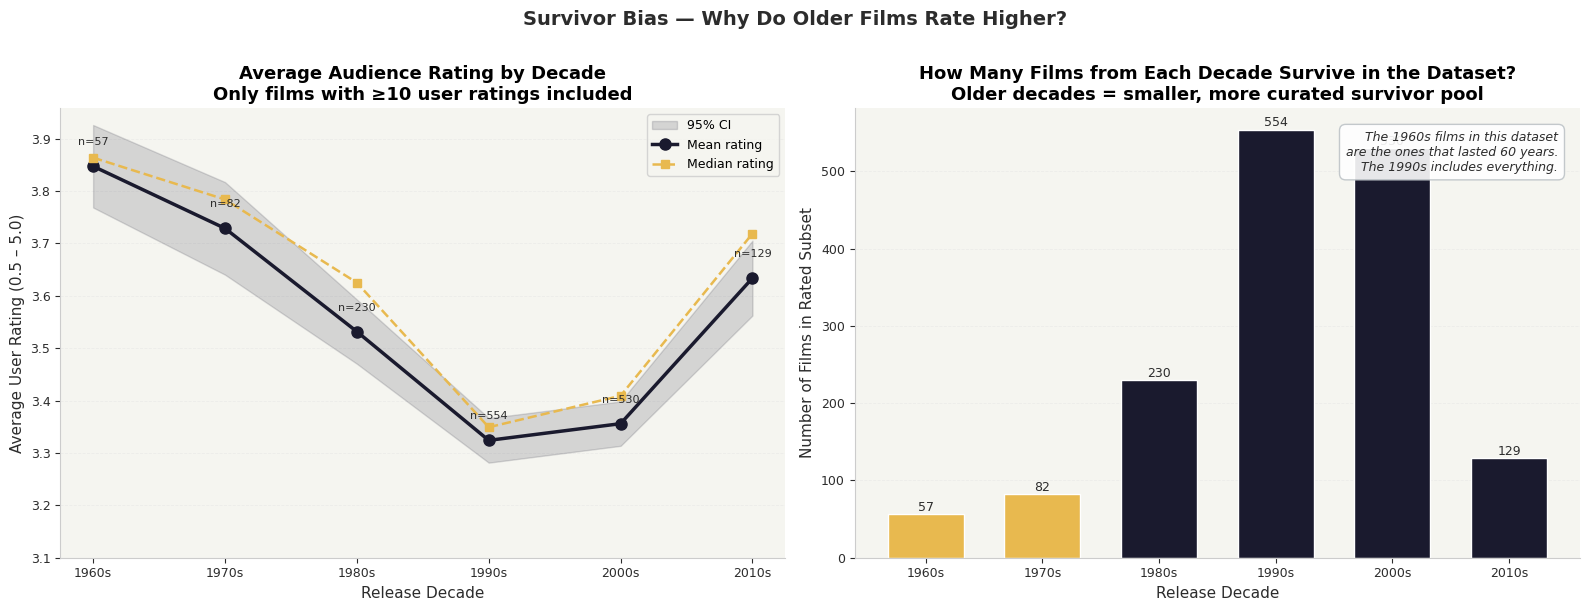

Saved: fig_B_survivor_bias.png


In [18]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Survivor Bias — Why Do Older Films Rate Higher?",
             fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.01)

decade_df = (
    df[df["decade"].between(1960, 2010)]
    .groupby("decade")["avg_user_rating"]
    .agg(mean="mean", se=sem, count="count", median="median")
    .reset_index()
)
decade_df["decade_label"] = decade_df["decade"].astype(int).astype(str) + "s"

# ── Left: mean rating by decade with 95% CI ────────────────────────
ax = axes[0]
ax.fill_between(decade_df["decade"],
                decade_df["mean"] - 1.96*decade_df["se"],
                decade_df["mean"] + 1.96*decade_df["se"],
                color=MIDNIGHT, alpha=0.15, label="95% CI")
ax.plot(decade_df["decade"], decade_df["mean"],
        color=MIDNIGHT, linewidth=2.5, marker="o", markersize=8, label="Mean rating")
ax.plot(decade_df["decade"], decade_df["median"],
        color=GOLD, linewidth=1.8, marker="s", markersize=6,
        linestyle="--", label="Median rating")

# Annotate n per decade
for _, row in decade_df.iterrows():
    ax.text(row["decade"], row["mean"] + 0.04,
            f"n={int(row['count'])}", ha="center", fontsize=8, color=DARK_TEXT)

ax.set_xlabel("Release Decade", fontsize=11)
ax.set_ylabel("Average User Rating (0.5 – 5.0)", fontsize=11)
ax.set_title("""Average Audience Rating by Decade
Only films with ≥10 user ratings included""")
ax.set_xticks(decade_df["decade"])
ax.set_xticklabels(decade_df["decade_label"])
ax.legend(fontsize=9)
ax.set_ylim(bottom=3.1)
style_spines(ax)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# ── Right: Film volume per decade — the survivor base ──────────────
ax2 = axes[1]
# Show both total films released vs films in our rated subset
total_by_decade = df[df["decade"].between(1960,2010)].groupby("decade").size().rename("rated_subset")
colors_b = [GOLD if d >= 1960 and d <= 1970 else MIDNIGHT
            for d in decade_df["decade"]]

bars = ax2.bar(decade_df["decade_label"], decade_df["count"],
               color=colors_b, edgecolor="white", width=0.65)
ax2.set_xlabel("Release Decade", fontsize=11)
ax2.set_ylabel("Number of Films in Rated Subset", fontsize=11)
ax2.set_title("""How Many Films from Each Decade Survive in the Dataset?
Older decades = smaller, more curated survivor pool""")
style_spines(ax2)
ax2.yaxis.grid(True, alpha=0.4)
ax2.set_axisbelow(True)

for bar, (_, row) in zip(bars, decade_df.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 4,
             f"{int(row['count'])}", ha="center", fontsize=9, color=DARK_TEXT)

ax2.text(0.97, 0.95,
         "The 1960s films in this dataset\nare the ones that lasted 60 years.\nThe 1990s includes everything.",
         transform=ax2.transAxes, ha="right", va="top", fontsize=9,
         color=DARK_TEXT, style="italic",
         bbox=dict(boxstyle="round,pad=0.5", fc="white", ec=SILVER, alpha=0.9))

plt.tight_layout()
plt.savefig("fig_B_survivor_bias.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig_B_survivor_bias.png")

## Figure C · Crowd Wisdom: More Ratings → Higher Scores

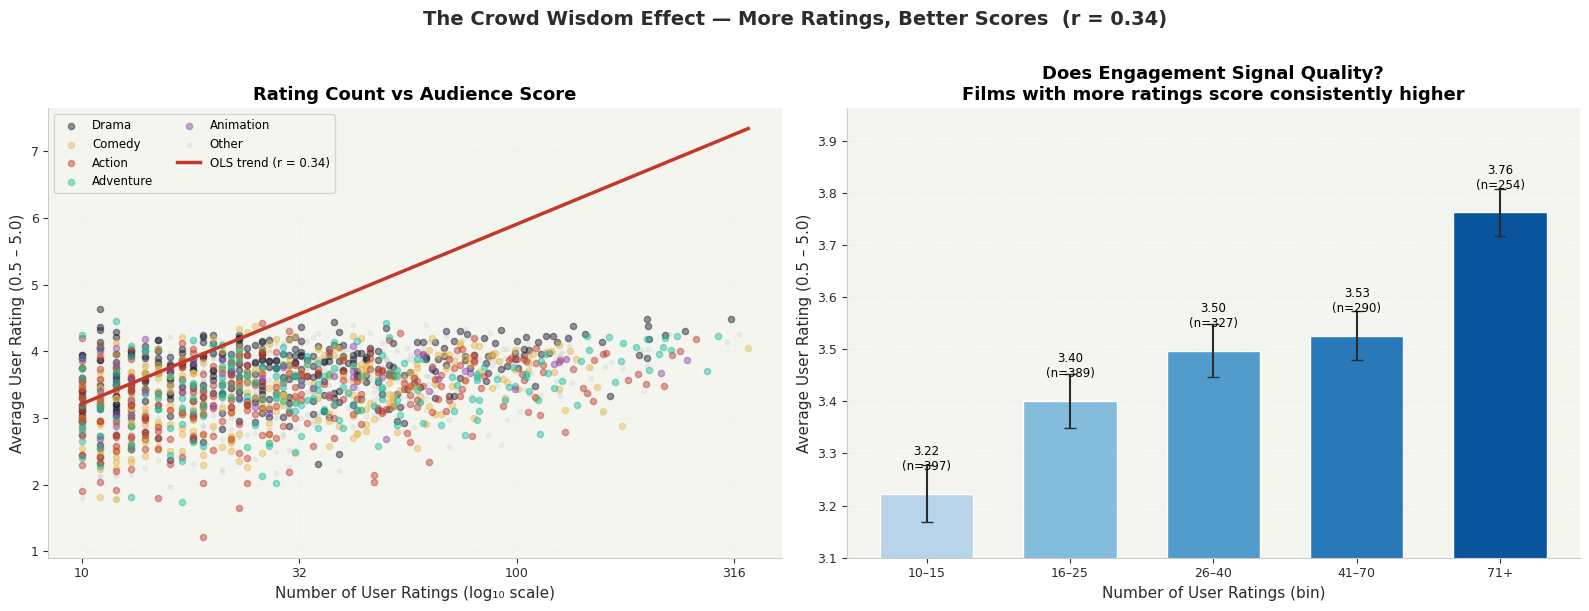

Saved: fig_C_crowd_wisdom.png


In [19]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

r_cnt, _ = pearsonr(df["log_count"], df["avg_user_rating"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"The Crowd Wisdom Effect — More Ratings, Better Scores  (r = {r_cnt:.2f})",
             fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.01)

# ── Left: scatter with OLS + genre colouring ──────────────────────
ax = axes[0]
TOP_GENRES = ["Drama","Comedy","Action","Adventure","Animation"]
PAL = [MIDNIGHT, GOLD, CRIMSON, TEAL, PURPLE]

for genre, color in zip(TOP_GENRES, PAL):
    sub = df[df["primary_genre"] == genre]
    ax.scatter(sub["log_count"], sub["avg_user_rating"],
               color=color, alpha=0.45, s=20, label=genre, zorder=3)
others = df[~df["primary_genre"].isin(TOP_GENRES)]
ax.scatter(others["log_count"], others["avg_user_rating"],
           color=SILVER, alpha=0.2, s=10, label="Other", zorder=2)

b, m = npfit(df["log_count"], df["avg_user_rating"], deg=1)
xs = np.linspace(df["log_count"].min(), df["log_count"].max(), 200)
ax.plot(xs, m + b*xs, color=CRIMSON, linewidth=2.5,
        zorder=5, label=f"OLS trend (r = {r_cnt:.2f})")

ax.set_xlabel("Number of User Ratings (log₁₀ scale)", fontsize=11)
ax.set_ylabel("Average User Rating (0.5 – 5.0)", fontsize=11)
ax.set_title("Rating Count vs Audience Score")
ax.set_xticks([1, 1.5, 2, 2.5])
ax.set_xticklabels(["10", "32", "100", "316"])
ax.legend(fontsize=8.5, framealpha=0.8, ncol=2)
style_spines(ax)
ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# ── Right: binned means — the staircase pattern ────────────────────
ax = axes[1]
df["count_bin"] = pd.cut(df["rating_count"],
    bins=[0, 15, 25, 40, 70, 341],
    labels=["10–15", "16–25", "26–40", "41–70", "71+"])

bin_stats = (
    df.groupby("count_bin", observed=True)["avg_user_rating"]
    .agg(mean="mean", se=sem, count="count")
    .reset_index()
)

colors_c = [plt.cm.Blues(0.3 + 0.14*i) for i in range(len(bin_stats))]
bars = ax.bar(bin_stats["count_bin"].astype(str), bin_stats["mean"],
              yerr=bin_stats["se"] * 1.96,
              color=colors_c, edgecolor="white",
              capsize=4, error_kw={"ecolor": DARK_TEXT, "lw": 1.5},
              width=0.65)

ax.set_ylim(bottom=3.1, top=bin_stats["mean"].max() + 0.2)
ax.set_xlabel("Number of User Ratings (bin)", fontsize=11)
ax.set_ylabel("Average User Rating (0.5 – 5.0)", fontsize=11)
ax.set_title("""Does Engagement Signal Quality?
Films with more ratings score consistently higher""")
style_spines(ax)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

for bar, (_, row) in zip(bars, bin_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.04,
            f"{row['mean']:.2f}\n(n={int(row['count'])})",
            ha="center", va="bottom", fontsize=8.5)

plt.tight_layout()
plt.savefig("fig_C_crowd_wisdom.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig_C_crowd_wisdom.png")

## Figure D · Genre Quality vs Polarisation Matrix

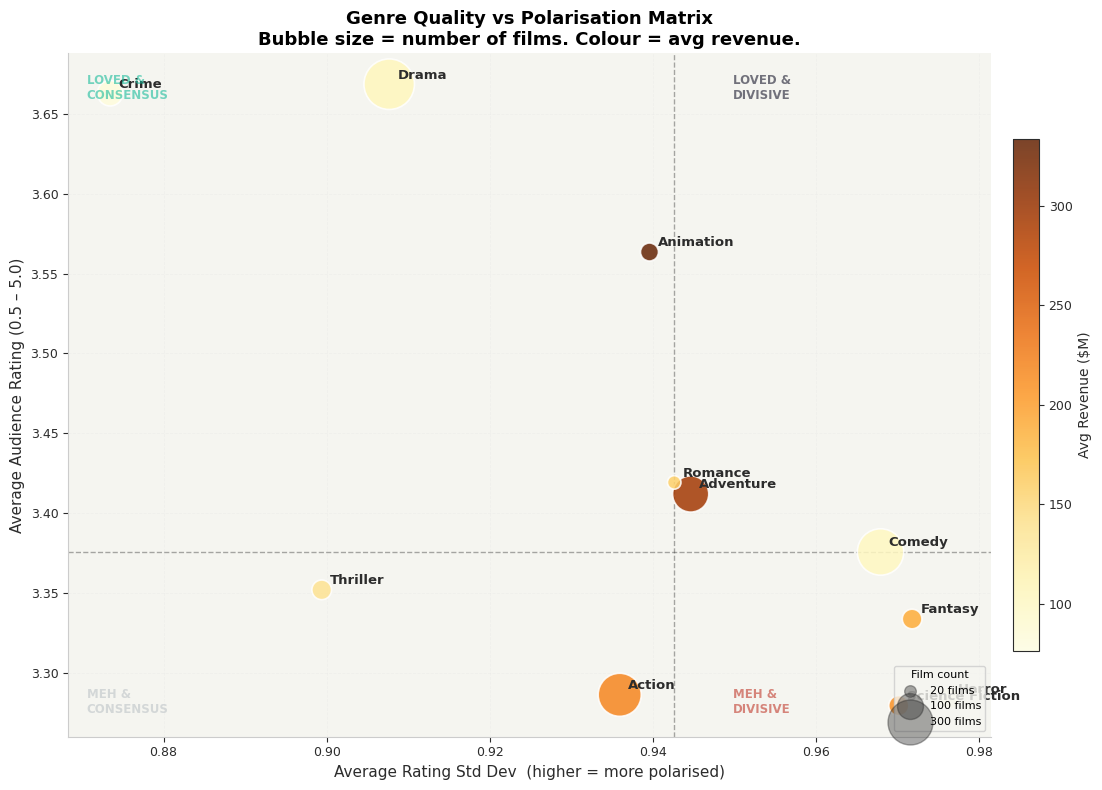

Saved: fig_D_genre_quality_matrix.png


In [20]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, ax = plt.subplots(figsize=(12, 8))

genre_stats = (
    df.groupby("primary_genre")
    .agg(n=("title","count"),
         avg_rating=("avg_user_rating","mean"),
         avg_std=("rating_std","mean"),
         avg_revenue_M=("revenue", lambda x: x.mean()/1e6))
    .query("n >= 20")
    .reset_index()
)

# Bubble size = film count, colour = avg revenue
sc = ax.scatter(
    genre_stats["avg_std"],
    genre_stats["avg_rating"],
    s=genre_stats["n"] * 3.5,
    c=genre_stats["avg_revenue_M"],
    cmap="YlOrBr",
    alpha=0.85,
    edgecolors="white",
    linewidths=1.2,
    zorder=3
)
cbar = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("Avg Revenue ($M)", fontsize=10)

for _, row in genre_stats.iterrows():
    ax.annotate(row["primary_genre"],
                xy=(row["avg_std"], row["avg_rating"]),
                xytext=(6, 4), textcoords="offset points",
                fontsize=9.5, color=DARK_TEXT, fontweight="bold")

# Quadrant reference lines at medians
x_med = genre_stats["avg_std"].median()
y_med = genre_stats["avg_rating"].median()
ax.axvline(x_med, color=DARK_TEXT, linewidth=1, linestyle="--", alpha=0.4)
ax.axhline(y_med, color=DARK_TEXT, linewidth=1, linestyle="--", alpha=0.4)

# Quadrant labels
pad = 0.012
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

quadrant_labels = [
    (0.02,  0.97, """LOVED &
CONSENSUS""",  TEAL),
    (0.72,  0.97, """LOVED &
DIVISIVE""",   MIDNIGHT),
    (0.02,  0.03, """MEH &
CONSENSUS""",    SILVER),
    (0.72,  0.03, """MEH &
DIVISIVE""",     CRIMSON),
]
for xf, yf, label, color in quadrant_labels:
    ax.text(xf, yf, label, transform=ax.transAxes,
            fontsize=8.5, color=color, alpha=0.6,
            fontweight="bold", ha="left", va="top" if yf > 0.5 else "bottom")

ax.set_xlabel("Average Rating Std Dev  (higher = more polarised)", fontsize=11)
ax.set_ylabel("Average Audience Rating (0.5 – 5.0)", fontsize=11)
ax.set_title("""Genre Quality vs Polarisation Matrix
Bubble size = number of films. Colour = avg revenue.""",
             fontsize=13, fontweight="bold")

# Legend for bubble size
for n_, label_ in [(20,"20 films"), (100,"100 films"), (300,"300 films")]:
    ax.scatter([], [], s=n_*3.5, color=DARK_TEXT, alpha=0.4, label=label_)
ax.legend(title="Film count", fontsize=8, title_fontsize=8,
          framealpha=0.8, loc="lower right")

style_spines(ax)
ax.grid(True, alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig_D_genre_quality_matrix.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig_D_genre_quality_matrix.png")

## Figure E · Where the Two Rating Systems Disagree

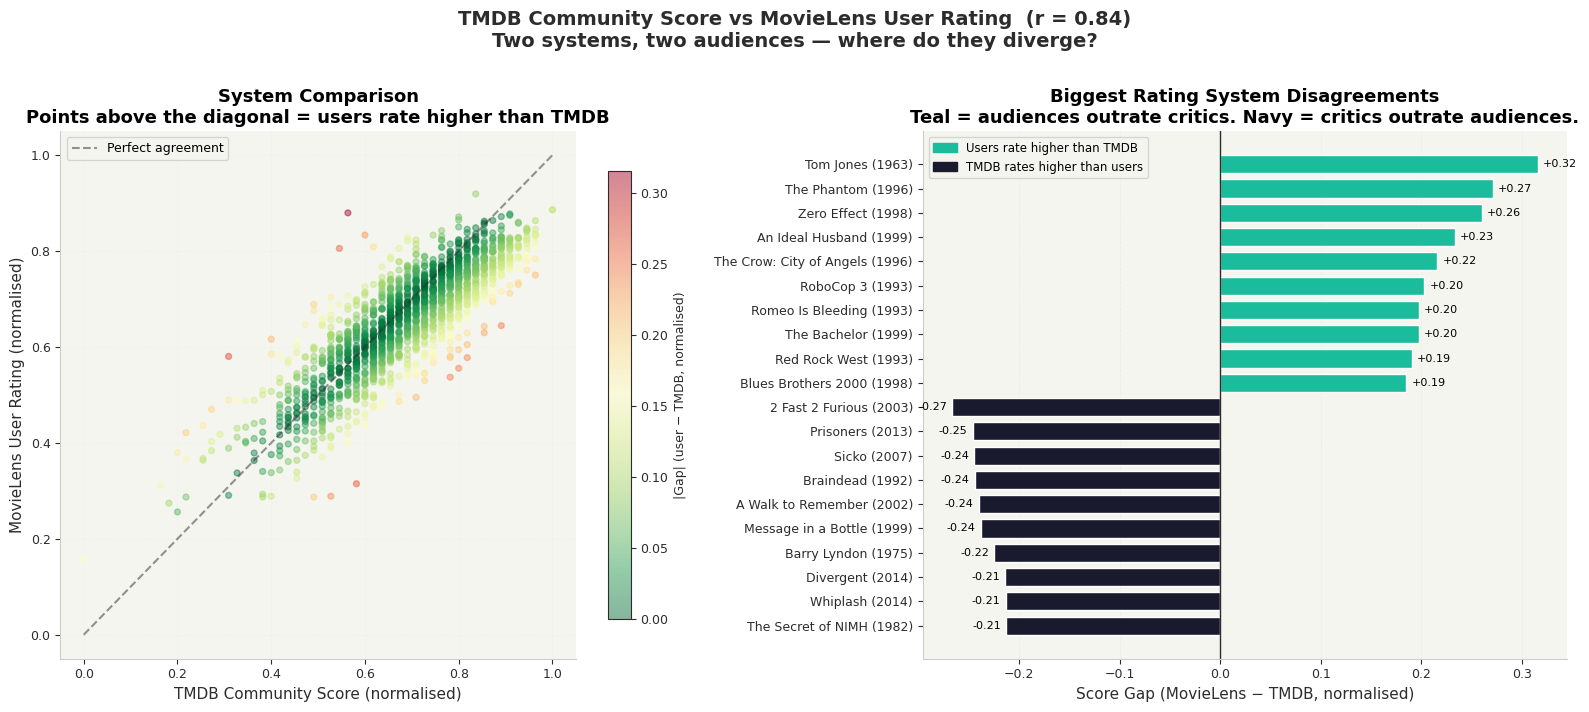

Saved: fig_E_system_divergence.png


In [21]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

r_sys, _ = pearsonr(df["vote_norm"], df["rating_norm"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"""TMDB Community Score vs MovieLens User Rating  (r = {r_sys:.2f})
Two systems, two audiences — where do they diverge?""",
             fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.01)

# ── Left: scatter of the two normalised systems ────────────────────
ax = axes[0]

# Colour by |gap| magnitude
gap_abs = df["score_gap"].abs()
sc = ax.scatter(df["vote_norm"], df["rating_norm"],
                c=gap_abs, cmap="RdYlGn_r",
                alpha=0.45, s=18, zorder=3)
cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("|Gap| (user − TMDB, normalised)", fontsize=9)

# Perfect agreement diagonal
ax.plot([0, 1], [0, 1], color=DARK_TEXT, linewidth=1.5,
        linestyle="--", alpha=0.5, label="Perfect agreement", zorder=4)

ax.set_xlabel("TMDB Community Score (normalised)", fontsize=11)
ax.set_ylabel("MovieLens User Rating (normalised)", fontsize=11)
ax.set_title("""System Comparison
Points above the diagonal = users rate higher than TMDB""")
ax.legend(fontsize=9)
style_spines(ax)
ax.grid(True, alpha=0.25)
ax.set_axisbelow(True)

# ── Right: Top divergers in each direction ─────────────────────────
ax = axes[1]

top_user_wins  = df.nlargest(10, "score_gap").sort_values("score_gap")   # users >> TMDB
top_tmdb_wins  = df.nsmallest(10,"score_gap").sort_values("score_gap", ascending=False)  # TMDB >> users

labels_u = [f"{r['title']} ({int(r['release_year'])})" for _, r in top_user_wins.iterrows()]
labels_t = [f"{r['title']} ({int(r['release_year'])})" for _, r in top_tmdb_wins.iterrows()]
all_labels = labels_t + labels_u
all_vals   = list(top_tmdb_wins["score_gap"]) + list(top_user_wins["score_gap"])
all_colors = [MIDNIGHT]*10 + [TEAL]*10

ax.barh(all_labels, all_vals, color=all_colors, edgecolor="white", height=0.75)
ax.axvline(0, color=DARK_TEXT, linewidth=1)

ax.set_xlabel("Score Gap (MovieLens − TMDB, normalised)", fontsize=11)
ax.set_title("""Biggest Rating System Disagreements
Teal = audiences outrate critics. Navy = critics outrate audiences.""")
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

for p, val in zip(ax.patches, all_vals):
    ha = "left" if val >= 0 else "right"
    offset = 0.005 if val >= 0 else -0.005
    ax.text(val + offset, p.get_y() + p.get_height()/2,
            f"{val:+.2f}", va="center", ha=ha, fontsize=8)

teal_patch  = mpatches.Patch(color=TEAL,    label="Users rate higher than TMDB")
navy_patch  = mpatches.Patch(color=MIDNIGHT, label="TMDB rates higher than users")
ax.legend(handles=[teal_patch, navy_patch], fontsize=8.5, framealpha=0.8)

plt.tight_layout()
plt.savefig("fig_E_system_divergence.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig_E_system_divergence.png")

## Figure F · The Full Picture: Decade × Genre Rating Heatmap

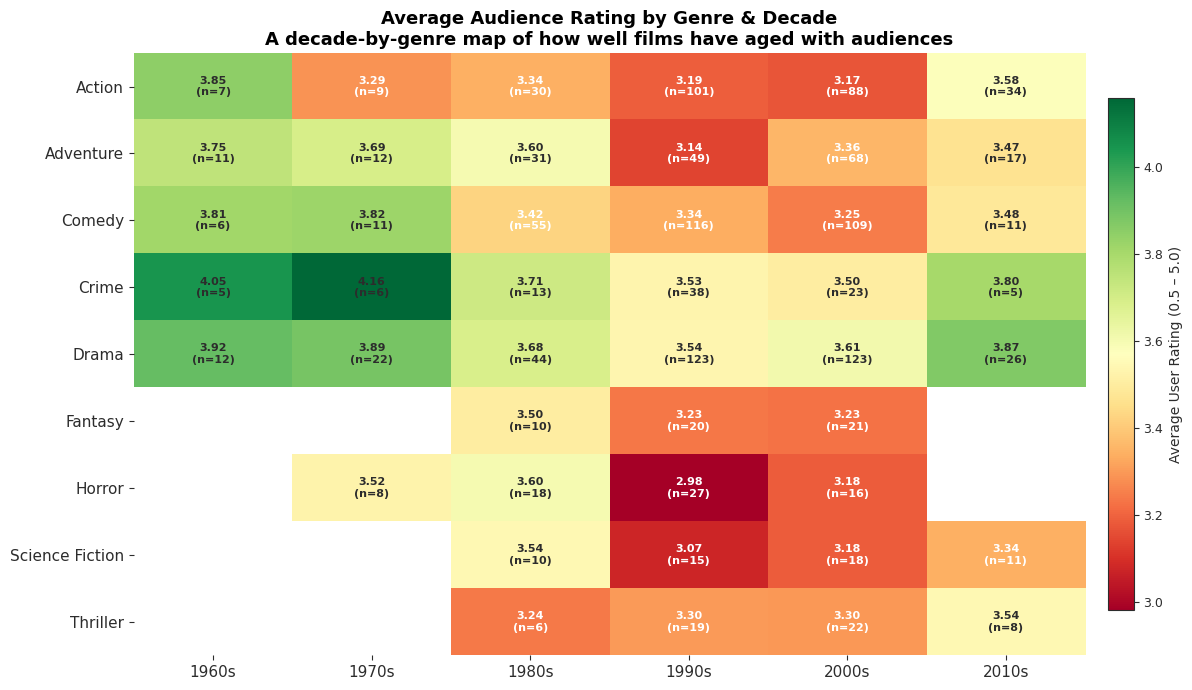

In [22]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

import matplotlib.colors as mcolors

# Only decades/genres with enough films for stable means
TOP_GENRES = (df["primary_genre"].value_counts()
                .loc[lambda s: s >= 20].head(9).index.tolist())

pivot = (
    df[df["decade"].between(1960, 2010) & df["primary_genre"].isin(TOP_GENRES)]
    .groupby(["decade","primary_genre"])["avg_user_rating"]
    .agg(mean="mean", count="count")
    .reset_index()
    .query("count >= 5")
    .pivot(index="primary_genre", columns="decade", values="mean")
)

# Fill gaps with NaN so they render as blank cells
pivot.columns = [f"{int(c)}s" for c in pivot.columns]

fig, ax = plt.subplots(figsize=(13, 7))

vmin = pivot.min().min()
vmax = pivot.max().max()
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto",
               vmin=vmin, vmax=vmax)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)

# Annotate cells — show mean and suppress cells with too few films
count_pivot = (
    df[df["decade"].between(1960, 2010) & df["primary_genre"].isin(TOP_GENRES)]
    .groupby(["decade","primary_genre"])["avg_user_rating"]
    .count()
    .reset_index()
    .pivot(index="primary_genre", columns="decade", values="avg_user_rating")
)
count_pivot.columns = [f"{int(c)}s" for c in count_pivot.columns]

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val   = pivot.iloc[i, j]
        n_val = count_pivot.iloc[i, j] if not count_pivot.iloc[i, j] != count_pivot.iloc[i, j] else count_pivot.iloc[i, j]
        if not np.isnan(val):
            norm_val = (val - vmin) / (vmax - vmin)
            text_color = "white" if norm_val < 0.4 else DARK_TEXT
            ax.text(j, i, f"""{val:.2f}
(n={int(n_val)})""",
                    ha="center", va="center",
                    fontsize=8, color=text_color, fontweight="bold")

cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label("Average User Rating (0.5 – 5.0)", fontsize=10)

ax.set_title("Average Audience Rating by Genre & Decade\n"
             "A decade-by-genre map of how well films have aged with audiences",
             fontsize=13, fontweight="bold")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_facecolor("white")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.savefig("fig_F_decade_genre_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

## ✅ All Six Figures Complete

### What each figure tells your reader

**Figure A — Revenue vs ROI:** The big reveal. Revenue is uncorrelated with audience love
(r ≈ −0.02). But financial *efficiency* (ROI) shows a clean monotonic relationship — studios
that spent their budgets wisely tended to make films people actually enjoyed. The contrast
between the two panels is the entire newsletter in a single figure.

**Figure B — Survivor Bias:** The reason 1960s films rate higher isn't because filmmaking was
better. It's because only the films worth remembering have been rated at all. The volume panel
makes this concrete: 57 films from the 1960s survive in the dataset vs 554 from the 1990s.

**Figure C — Crowd Wisdom:** Films that attract more ratings score higher — not because
rating count causes quality, but because quality films attract sustained engagement. The
binned staircase on the right removes noise and makes the trend unambiguous.

**Figure D — Genre Matrix:** Positions every major genre in quality-polarisation space.
Drama sits in the "loved and calm" quadrant. Horror sits opposite. Comedy lands in the
middle on both axes. The bubble size and revenue colour add a third and fourth dimension
without cluttering the read.

**Figure E — System Divergence:** Validates the analysis (the two systems agree at r = 0.84)
while surfacing the interesting exceptions. The films where casual MovieLens users and the
broader TMDB community most disagree tend to be cult films, foreign language films, or
genre fare that resonates very differently with different audience types.

**Figure F — Decade × Genre Heatmap:** The most information-dense figure in the series.
Readers can scan horizontally to see how a genre's reputation has evolved, or vertically to
compare genres in any given decade. Blank cells are honest about data gaps rather than
extrapolating.


In [23]:
saved = [
    "fig_A_revenue_vs_roi.png",
    "fig_B_survivor_bias.png",
    "fig_C_crowd_wisdom.png",
    "fig_D_genre_quality_matrix.png",
    "fig_E_system_divergence.png",
    "fig_F_decade_genre_heatmap.png",
]
print("Extended insight figures:")
for f in saved:
    print(f"  ✔  {f}")


Extended insight figures:
  ✔  fig_A_revenue_vs_roi.png
  ✔  fig_B_survivor_bias.png
  ✔  fig_C_crowd_wisdom.png
  ✔  fig_D_genre_quality_matrix.png
  ✔  fig_E_system_divergence.png
  ✔  fig_F_decade_genre_heatmap.png
